# Hasse Search Space Estimation

## Setup

In [14]:
import json
import numpy as np
import os
from pprint import pprint
from statistics import mean, stdev
from typing import List, Dict

In [15]:
%pip install matplotlib
import matplotlib.pyplot as plt

You should consider upgrading via the '/Users/christophstein/Documents/jku/gospl/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## Util functions

In [16]:
def printb(text: str) -> None:
    print("\033[1m" + text + "\033[0m")

In [17]:
def load_json(path: str) -> Dict:
    with open(path, "r") as json_file:
        return json.load(json_file)

## Load Data

In [18]:
def load_experiments(results_dir: str = "results") -> List:
    experiments = []

    for file_name in os.listdir(results_dir):
        if not file_name.endswith(".json"):
            continue

        experiment = load_json(f"{results_dir}/{file_name}")
        experiments.append(experiment)

    return experiments

In [19]:
def filter_experiments(experiments: List, params: Dict={}, prefix=None) -> List:
    filtered_experiments = []

    for experiment in experiments:
        if prefix is not None and not experiment["meta"]["experiment_prefix"].startswith(prefix):
            continue

        all_params_match = True
        for key in params:
            if experiment["params"][key] != params[key]:
                all_params_match = False
                break

        if all_params_match:
            filtered_experiments.append(experiment)

    return filtered_experiments

In [20]:
def sort_experiments(experiments: List, key: str):
    experiments.sort(key=lambda experiment: experiment["params"][key])

In [21]:
def get_buffer_counts(experiments: List, sorted=True) -> List[int]:

    buffer_counts = []
    add_none = False 

    for experiment in experiments:

        if experiment["params"]["buffer_qubits"] is not None:
            buffer_counts.append(experiment["params"]["buffer_qubits"])
        else:
            add_none = True

    buffer_counts = list(set(buffer_counts))

    if sorted:
        buffer_counts.sort()

    if add_none:
        buffer_counts.append(None)

    return buffer_counts

In [22]:
def get_probabilities(experiments: List, constraint_violations: int = 0) -> List[float]:
    probabilities = []

    for experiment in experiments:

        for result in experiment["results"]:
            if result["constraint_violations"] == constraint_violations:
                probabilities.append(result["mean_prob"])
                break 

    return probabilities

In [23]:
def get_constraint_counts(experiments: List) -> List[float]:
    constraint_counts = []

    for experiment in experiments:
        constraint_counts.append(experiment["encoding"]["constraints"])

    return constraint_counts

## Visualization Functions

In [24]:
def plot_probability_per_buffer_count(experiments: List, target_path: None):
    buffer_counts = get_buffer_counts(experiments)

    x = []
    mean_probabilities = []
    std_probabilities = []

    for buffer_count in buffer_counts:
        rel_experiments = filter_experiments(experiments, params={
            "buffer_qubits": buffer_count
        })

        if buffer_count is None:
            # Depending on how the problem instance is initialized,
            # constraint counts and therefore buffer qubit counts
            # might deviate slightly.
            x.append(max(get_constraint_counts(rel_experiments)))
        else:
            x.append(buffer_count)

        probabilities = get_probabilities(
            rel_experiments, constraint_violations=0)

        if len(probabilities) > 1:
            mean_probabilities.append(mean(probabilities))
            std_probabilities.append(stdev(probabilities))
        else:
            mean_probabilities.append(0)
            std_probabilities.append(0)

    ax = plt.subplot()

    ax.plot(x, mean_probabilities)

    lower_bounds = [value - std for value, std in zip(mean_probabilities, std_probabilities)]
    upper_bounds = [value + std for value, std in zip(mean_probabilities, std_probabilities)]
    
    ax.fill_between(
        x, lower_bounds, upper_bounds, alpha=0.2
    )

    ax.set_xlabel("buffer qubits")
    ax.set_ylabel("probability")
    ax.set_xticks(x)

    ax.set_ylim(0)

    plt.grid()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

## Data Analysis

In [25]:
experiments = load_experiments()

sudoku_experiments = filter_experiments(experiments, prefix="sudoku")
graph_coloring_experiments = filter_experiments(experiments, prefix="graph_coloring")

print(f"Number of sudoku experiments: {len(sudoku_experiments)}")
print(f"Number of graph coloring experiments: {len(graph_coloring_experiments)}")

Number of sudoku experiments: 50
Number of graph coloring experiments: 0


Probability of measuring a correct solution (avg. across seeds)


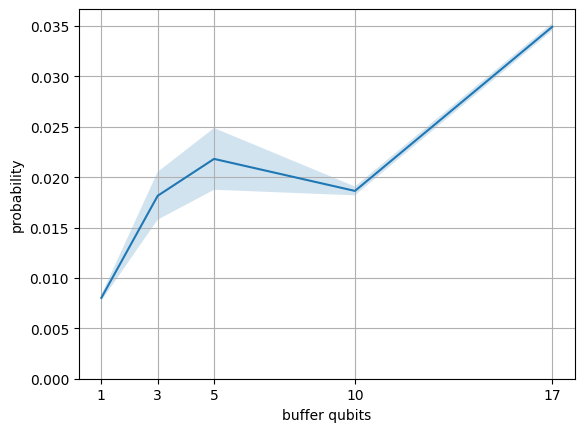

<Figure size 640x480 with 0 Axes>

In [ ]:
printb("Probability of measuring a correct solution (avg. across seeds)")

plot_probability_per_buffer_count(
    sudoku_experiments, target_path=f"results/sudoku_probabilities.png"
)

In [27]:
# 